# Notebook 06 — Calibration, Explainability, and Decision Support

## Objective

This notebook completes the final analytical stage of the multi-modal credit-risk
study.

Using the model results established in the preceding notebooks, it evaluates the
selected hybrid model from three perspectives:

1. probability calibration and reliability;
2. model explainability; and
3. translation of predicted default probabilities into a simple risk-based
   decision-support framework.

The analysis is restricted to the previously defined temporal train, validation,
and held-out 2014 test cohorts. No additional predictive model families are
introduced in this notebook.

The objective is to determine whether the selected model produces outputs that
are sufficiently interpretable and probabilistically meaningful to support
transparent Approve, Review, and Reject risk categories.

## 1. Environment and Artifact Setup

This section initializes the notebook environment, defines the project paths,
and verifies that the required outputs from Notebook 05 are available before
the final evaluation begins.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

from google.colab import drive

drive.mount("/content/drive")

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Credit_Risk_Thesis"
)

PROCESSED_DATA_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

NB5_OUTPUT_DIR = (
    PROCESSED_DATA_DIR / "notebook_05"
)

NB6_OUTPUT_DIR = (
    PROCESSED_DATA_DIR / "notebook_06"
)

NB6_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Notebook 05:", NB5_OUTPUT_DIR)
print("Notebook 06:", NB6_OUTPUT_DIR)

Mounted at /content/drive
Notebook 05: /content/drive/MyDrive/Credit_Risk_Thesis/data/processed/notebook_05
Notebook 06: /content/drive/MyDrive/Credit_Risk_Thesis/data/processed/notebook_06


### 1.1 Verify Notebook 05 Handoff

The final evaluation depends on persisted comparison and calibration artifacts
from Notebook 05. Their availability is verified before loading any results.


In [2]:
required_nb5_files = [
    "final_representation_comparison.csv",
    "matched_representation_calibration.csv",
    "representation_paired_bootstrap_comparison.csv",
    "hybrid_validation_comparison.csv",
    "structured_tfidf_logistic_model.joblib",
    "tfidf_vectorizer.joblib",
    "matched_categorical_encoder.joblib",
    "matched_numeric_scaler.joblib",
    "matched_numerical_feature_names.json",
    "structured_tfidf_val_prob.npy",
    "structured_tfidf_test_prob.npy",
    "y_text_val.npy",
    "y_text_test.npy",
    "shap_background_structured_tfidf.npz",
    "shap_explain_structured_tfidf.npz"
]

missing_nb5_files = []

for filename in required_nb5_files:
    path = NB5_OUTPUT_DIR / filename
    status = "FOUND" if path.exists() else "MISSING"
    print(filename, "->", status)

    if not path.exists():
        missing_nb5_files.append(filename)

assert not missing_nb5_files, (
    "Missing Notebook 05 handoff files: "
    + ", ".join(missing_nb5_files)
)

print("Notebook 05 handoff validated.")


final_representation_comparison.csv -> FOUND
matched_representation_calibration.csv -> FOUND
representation_paired_bootstrap_comparison.csv -> FOUND
hybrid_validation_comparison.csv -> FOUND
structured_tfidf_logistic_model.joblib -> FOUND
tfidf_vectorizer.joblib -> FOUND
matched_categorical_encoder.joblib -> FOUND
matched_numeric_scaler.joblib -> FOUND
matched_numerical_feature_names.json -> FOUND
structured_tfidf_val_prob.npy -> FOUND
structured_tfidf_test_prob.npy -> FOUND
y_text_val.npy -> FOUND
y_text_test.npy -> FOUND
shap_background_structured_tfidf.npz -> FOUND
shap_explain_structured_tfidf.npz -> FOUND
Notebook 05 handoff validated.


## 2. Final Model Selection

The final hybrid model is selected using the **2013 validation cohort only**.
This preserves the 2014 cohort as an untouched out-of-time test set for final
evaluation.

Notebook 05 produced validation results for the two principal hybrid
specifications. Structured + TF-IDF achieved the stronger validation ROC-AUC,
PR-AUC, and Brier score, so it is locked as the final research model before
test-cohort calibration, explainability, and decision-support results are
examined.

The held-out 2014 comparison remains important for reporting generalisation,
but it is not used to choose the final hybrid specification.


In [3]:
representation_comparison = pd.read_csv(
    NB5_OUTPUT_DIR / "final_representation_comparison.csv"
)

calibration_comparison = pd.read_csv(
    NB5_OUTPUT_DIR / "matched_representation_calibration.csv"
)

bootstrap_comparison = pd.read_csv(
    NB5_OUTPUT_DIR / "representation_paired_bootstrap_comparison.csv"
)

hybrid_validation_comparison = pd.read_csv(
    NB5_OUTPUT_DIR / "hybrid_validation_comparison.csv"
)

print("Validation-based hybrid comparison:")
display(hybrid_validation_comparison)

print("\nHeld-out 2014 representation comparison:")
display(representation_comparison)


Validation-based hybrid comparison:


,representation,selected_C,roc_auc,pr_auc,brier_score
0,Structured + TF-IDF,0.100,0.692268,0.281299,0.120925
1,Structured + BERT,0.001,0.690800,0.278100,0.121400



Held-out 2014 representation comparison:


,representation,roc_auc,pr_auc,brier_score
0,TF-IDF text-only,0.571466,0.194471,0.132339
1,BERT text-only,0.585693,0.201401,0.132398
2,Structured-only,0.678005,0.275648,0.126489
3,Structured + TF-IDF,0.683357,0.278794,0.126090
4,Structured + BERT,0.685176,0.276257,0.126880


In [4]:
SELECTED_MODEL = (
    hybrid_validation_comparison
    .sort_values("roc_auc", ascending=False)
    .iloc[0]["representation"]
)

selected_validation_row = hybrid_validation_comparison[
    hybrid_validation_comparison["representation"] == SELECTED_MODEL
].iloc[0]

selected_model_summary = pd.DataFrame([{
    "selected_model": SELECTED_MODEL,
    "selection_split": "Validation (2013)",
    "validation_roc_auc": selected_validation_row["roc_auc"],
    "validation_pr_auc": selected_validation_row["pr_auc"],
    "validation_brier_score": selected_validation_row["brier_score"],
    "selection_reason":
        "Highest validation ROC-AUC, PR-AUC, and lowest Brier score "
        "among the evaluated hybrid specifications"
}])

selected_model_summary.round(4)


,selected_model,selection_split,validation_roc_auc,validation_pr_auc,validation_brier_score,selection_reason
0,Structured + TF-IDF,Validation (2013),0.6923,0.2813,0.1209,"Highest validation ROC-AUC, PR-AUC, and lowest..."


In [5]:
selected_model_summary.to_csv(
    NB6_OUTPUT_DIR / "model_selection_summary.csv",
    index=False
)

print("Model selection summary saved.")


Model selection summary saved.


## 3. Calibration Assessment

Calibration decisions are made using the 2013 validation cohort before the
held-out 2014 test calibration is interpreted. This prevents the test cohort
from influencing whether post-hoc recalibration is applied.

Brier score, Expected Calibration Error (ECE), and the aggregate gap between
mean predicted probability and observed default rate are used as descriptive
probability-reliability measures.


### 3.1 Validation-Based Calibration Decision

The selected Structured + TF-IDF validation probabilities and validation target
are loaded from Notebook 05. Calibration is assessed on this cohort to decide
whether additional post-hoc recalibration is warranted.


In [6]:
selected_val_prob = np.load(
    NB5_OUTPUT_DIR / "structured_tfidf_val_prob.npy"
)

selected_test_prob = np.load(
    NB5_OUTPUT_DIR / "structured_tfidf_test_prob.npy"
)

y_text_val = np.load(
    NB5_OUTPUT_DIR / "y_text_val.npy"
)

y_text_test = np.load(
    NB5_OUTPUT_DIR / "y_text_test.npy"
)

assert len(selected_val_prob) == len(y_text_val)
assert len(selected_test_prob) == len(y_text_test)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(
        y_prob,
        bins[1:-1],
        right=True
    )

    ece = 0.0

    for bin_id in range(n_bins):
        mask = bin_ids == bin_id

        if mask.sum() == 0:
            continue

        observed = y_true[mask].mean()
        predicted = y_prob[mask].mean()

        ece += mask.mean() * abs(observed - predicted)

    return ece

validation_calibration = pd.DataFrame([{
    "split": "Validation (2013)",
    "brier_score": brier_score_loss(
        y_text_val,
        selected_val_prob
    ),
    "ece_10_bins": expected_calibration_error(
        y_text_val,
        selected_val_prob,
        n_bins=10
    ),
    "mean_predicted_probability":
        selected_val_prob.mean(),
    "observed_default_rate":
        y_text_val.mean()
}])

validation_calibration["absolute_probability_gap"] = (
    validation_calibration["mean_predicted_probability"]
    - validation_calibration["observed_default_rate"]
).abs()

validation_calibration.round(4)


,split,brier_score,ece_10_bins,mean_predicted_probability,observed_default_rate,absolute_probability_gap
0,Validation (2013),0.1209,0.0104,0.1615,0.1516,0.0099


### 3.2 Calibration Decision and Locked Test Assessment

The validation results are used to determine the calibration approach. Because
the selected model shows relatively small validation calibration error under the
measures used in this study, the raw probability stream is retained without an
additional post-hoc calibration model.

After this decision is fixed, the same raw probabilities are assessed on the
held-out 2014 test cohort for final reporting.


In [7]:
test_calibration = calibration_comparison[
    calibration_comparison["representation"] == SELECTED_MODEL
].copy()

test_calibration.insert(
    1,
    "split",
    "Test (2014)"
)

print("Validation calibration:")
display(validation_calibration.round(4))

print("\nHeld-out test calibration:")
display(test_calibration.round(4))


Validation calibration:


,split,brier_score,ece_10_bins,mean_predicted_probability,observed_default_rate,absolute_probability_gap
0,Validation (2013),0.1209,0.0104,0.1615,0.1516,0.0099



Held-out test calibration:


,representation,split,brier_score,ece_10_bins,mean_predicted_probability,observed_default_rate
3,Structured + TF-IDF,Test (2014),0.1261,0.0089,0.1639,0.1585


### 3.3 Calibration Conclusion

The decision not to add post-hoc recalibration is based on the validation
cohort, not on the held-out test outcomes. The raw Structured + TF-IDF
probabilities are therefore locked before final test evaluation.

On the 2014 test cohort, the model produced a Brier score of 0.1261 and a
10-bin ECE of 0.0089, with mean predicted default probability of 0.1639 versus
an observed default rate of 0.1585. These held-out results are reported as
evidence of the probability reliability achieved by the locked model under the
study's temporal evaluation design.

The calibration measures used here are descriptive and do not imply perfect
calibration.


## 4. Explainability of the Selected Hybrid Model

The proposal specifies SHAP-based explainability for the selected credit-risk
model. The final Structured + TF-IDF Logistic Regression model is therefore
interpreted using SHAP values computed on a deterministic sample of the exact
hybrid feature matrix persisted by Notebook 05.

The analysis is intentionally compact: it provides a global ranking of feature
contributions without introducing an additional predictive model or expanding
the scope into a full model-governance study.


### 4.1 Load Persisted Model Components and SHAP Samples

The fitted hybrid model, preprocessing objects, ordered feature definitions, and
small sparse matrix samples are loaded directly from Notebook 05.


In [8]:
import joblib
import json
import importlib.util
import subprocess
import sys
from scipy import sparse

if importlib.util.find_spec("shap") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "shap"
    ])

import shap

selected_hybrid_model = joblib.load(
    NB5_OUTPUT_DIR / "structured_tfidf_logistic_model.joblib"
)

tfidf_vectorizer = joblib.load(
    NB5_OUTPUT_DIR / "tfidf_vectorizer.joblib"
)

matched_encoder = joblib.load(
    NB5_OUTPUT_DIR / "matched_categorical_encoder.joblib"
)

matched_numeric_scaler = joblib.load(
    NB5_OUTPUT_DIR / "matched_numeric_scaler.joblib"
)

shap_background = sparse.load_npz(
    NB5_OUTPUT_DIR / "shap_background_structured_tfidf.npz"
)

shap_explain = sparse.load_npz(
    NB5_OUTPUT_DIR / "shap_explain_structured_tfidf.npz"
)

print("Selected hybrid model loaded.")
print("Model coefficient count:", selected_hybrid_model.coef_.shape[1])
print("SHAP background shape:", shap_background.shape)
print("SHAP explanation shape:", shap_explain.shape)


Selected hybrid model loaded.
Model coefficient count: 42524
SHAP background shape: (200, 42524)
SHAP explanation shape: (300, 42524)


### 4.2 Reconstruct and Validate Ordered Feature Definitions

The structured and TF-IDF feature names are reconstructed in the exact order
used when fitting the final hybrid model. This alignment is verified before
SHAP values are interpreted.


In [9]:
categorical_encoded_names = (
    matched_encoder.get_feature_names_out()
)

tfidf_feature_names = (
    tfidf_vectorizer.get_feature_names_out()
)

print(
    "Categorical encoded features:",
    len(categorical_encoded_names)
)

print(
    "TF-IDF features:",
    len(tfidf_feature_names)
)

Categorical encoded features: 25
TF-IDF features: 42436


In [10]:
import json

with open(
    NB5_OUTPUT_DIR / "matched_numerical_feature_names.json",
    "r"
) as f:
    numerical_feature_names = json.load(f)

print(
    "Numerical structured features:",
    len(numerical_feature_names)
)

Numerical structured features: 63


### 4.3 Validate Feature/Model Alignment


In [11]:
structured_feature_names = np.concatenate([
    np.array(numerical_feature_names),
    categorical_encoded_names
])

hybrid_feature_names = np.concatenate([
    structured_feature_names,
    tfidf_feature_names
])

print(
    "Structured feature names:",
    len(structured_feature_names)
)

print(
    "Hybrid feature names:",
    len(hybrid_feature_names)
)

print(
    "Model coefficients:",
    selected_hybrid_model.coef_.shape[1]
)

assert (
    len(hybrid_feature_names)
    == selected_hybrid_model.coef_.shape[1]
)

print("Feature-name alignment validated.")

Structured feature names: 88
Hybrid feature names: 42524
Model coefficients: 42524
Feature-name alignment validated.


### 4.4 Global SHAP Analysis

For Logistic Regression, SHAP decomposes predictions into additive feature
contributions relative to a background distribution. Mean absolute SHAP value
is used to summarize the global contribution magnitude across the sampled
held-out observations.

Because TF-IDF features are standardized differently from the structured
features and the hybrid space is high-dimensional, interpretation focuses on
the SHAP contribution scale rather than raw coefficient magnitude alone.


In [12]:
shap_explainer = shap.LinearExplainer(
    selected_hybrid_model,
    shap_background
)

shap_values = shap_explainer(
    shap_explain
)

mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)

shap_global_importance = pd.DataFrame({
    "feature": hybrid_feature_names,
    "feature_type": np.where(
        np.arange(len(hybrid_feature_names))
        < len(structured_feature_names),
        "Structured",
        "Text"
    ),
    "mean_abs_shap": mean_abs_shap
}).sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

shap_top20 = shap_global_importance.head(20)

shap_top20


,feature,feature_type,mean_abs_shap
0,fico_score,Structured,0.263114
1,term_ 36 months,Structured,0.208694
2,annual_inc,Structured,0.191390
3,loan_amnt,Structured,0.168779
4,num_rev_tl_bal_gt_0,Structured,0.168204
5,total_bc_limit,Structured,0.153399
6,home_ownership_MORTGAGE,Structured,0.141459
7,acc_open_past_24mths,Structured,0.125553
8,mths_since_last_record_missing,Structured,0.122588
9,purpose_credit_card,Structured,0.119612


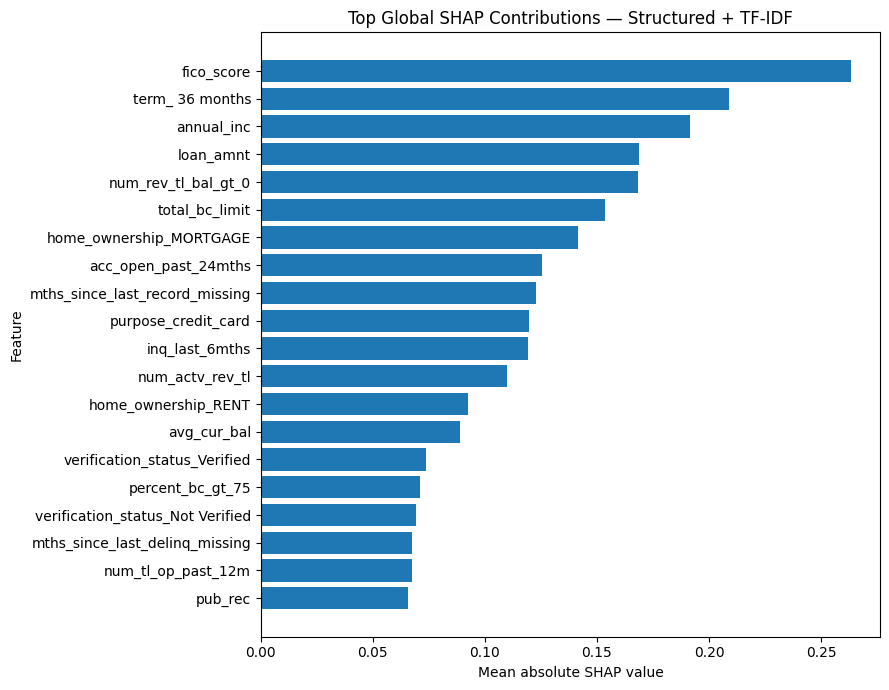

SHAP table saved.
SHAP figure saved: /content/drive/MyDrive/Credit_Risk_Thesis/data/processed/notebook_06/structured_tfidf_shap_top20.png


In [13]:
plt.figure(figsize=(9, 7))

plot_data = shap_top20.sort_values(
    "mean_abs_shap",
    ascending=True
)

plt.barh(
    plot_data["feature"],
    plot_data["mean_abs_shap"]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title(
    "Top Global SHAP Contributions — Structured + TF-IDF"
)

plt.tight_layout()

SHAP_FIGURE_PATH = (
    NB6_OUTPUT_DIR /
    "structured_tfidf_shap_top20.png"
)

plt.savefig(
    SHAP_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

shap_global_importance.to_csv(
    NB6_OUTPUT_DIR /
    "structured_tfidf_shap_global_importance.csv",
    index=False
)

print("SHAP table saved.")
print("SHAP figure saved:", SHAP_FIGURE_PATH)


### 4.5 Explainability Conclusion

The SHAP analysis provides a model-consistent global explanation of the selected
Structured + TF-IDF hybrid specification. The resulting ranking is used in the
dissertation to discuss which structured and textual features contributed most
strongly to the model's predictions.

These contributions describe predictive associations within the fitted model;
they are not interpreted as causal effects or as normative reasons to approve or
reject an applicant.


## 5. Risk-Based Decision-Support Layer

The final stage translates predicted default probabilities into an interpretable
risk-based decision-support framework.

Rather than treating the conventional 0.50 classification threshold as a lending
decision rule, borrowers are grouped into three risk bands representing lower,
intermediate, and higher predicted default risk.

Decision thresholds are determined using the validation cohort rather than the
held-out test cohort. The resulting thresholds are then fixed and applied to the
2014 test cohort to evaluate the distribution and observed default behaviour
within each risk band.

The resulting categories are intended as a research-oriented decision-support
illustration rather than as an operational lending policy.

### 5.1 Reuse Locked Validation and Test Probabilities

The probability streams loaded during calibration assessment are reused here.
Decision thresholds are derived from validation probabilities only and are then
applied unchanged to the held-out test cohort.


In [14]:
print("Validation probabilities:", selected_val_prob.shape)
print("Test probabilities:", selected_test_prob.shape)
print("Validation targets:", y_text_val.shape)
print("Test targets:", y_text_test.shape)

assert len(selected_val_prob) == len(y_text_val)
assert len(selected_test_prob) == len(y_text_test)

print(
    "\nValidation probability range:",
    round(selected_val_prob.min(), 4),
    "to",
    round(selected_val_prob.max(), 4)
)

print(
    "Validation probability mean:",
    round(selected_val_prob.mean(), 4)
)


Validation probabilities: (48726,)
Test probabilities: (15175,)
Validation targets: (48726,)
Test targets: (15175,)

Validation probability range: 0.0 to 0.7948
Validation probability mean: 0.1615


### 5.2 Validation Probability Distribution

The validation probability distribution is inspected to support a transparent
choice of risk-band thresholds without using the held-out test outcomes.


In [15]:
probability_summary = pd.Series(
    selected_val_prob
).describe(
    percentiles=[
        0.10,
        0.25,
        0.50,
        0.75,
        0.90,
        0.95
    ]
)

probability_summary

,0
count,4.872600e+04
mean,1.615357e-01
std,1.055376e-01
min,2.592210e-18
10%,5.122411e-02
25%,8.532696e-02
50%,1.371757e-01
75%,2.124526e-01
90%,3.072618e-01
95%,3.741545e-01


### 5.3 Define Validation-Derived Risk Thresholds

The median validation probability defines the lower/intermediate risk boundary,
while the 90th percentile defines the intermediate/higher risk boundary. These
thresholds are intended for research-oriented risk stratification rather than
as optimized operational lending rules.


In [16]:
LOW_RISK_THRESHOLD = np.quantile(
    selected_val_prob,
    0.50
)

HIGH_RISK_THRESHOLD = np.quantile(
    selected_val_prob,
    0.90
)

print(
    "Approve / Review threshold:",
    round(LOW_RISK_THRESHOLD, 4)
)

print(
    "Review / Reject threshold:",
    round(HIGH_RISK_THRESHOLD, 4)
)

Approve / Review threshold: 0.1372
Review / Reject threshold: 0.3073


In [17]:
def assign_risk_decision(probabilities):
    return np.where(
        probabilities < LOW_RISK_THRESHOLD,
        "Approve",
        np.where(
            probabilities < HIGH_RISK_THRESHOLD,
            "Review",
            "Reject"
        )
    )

### 5.4 Apply Fixed Thresholds to the Test Cohort

The validation-derived thresholds are applied unchanged to the temporally later
2014 test cohort. The held-out outcomes are used only to evaluate the resulting
risk stratification.


In [18]:
print("Test target:", y_text_test.shape)
print("Defaults:", int(y_text_test.sum()))
print(
    "Default rate:",
    round(y_text_test.mean(), 4)
)

assert len(y_text_test) == len(selected_test_prob)

print("Test target and probabilities aligned.")


Test target: (15175,)
Defaults: 2405
Default rate: 0.1585
Test target and probabilities aligned.


In [19]:
test_decisions = assign_risk_decision(
    selected_test_prob
)

decision_results = pd.DataFrame({
    "predicted_default_probability":
        selected_test_prob,
    "observed_default":
        y_text_test,
    "decision":
        test_decisions
})

decision_results.head()

,predicted_default_probability,observed_default,decision
0,0.100015,0,Approve
1,0.069958,0,Approve
2,0.181942,1,Review
3,0.165403,0,Review
4,0.130326,0,Approve


### 5.5 Evaluate Risk Stratification

Observed default rates and mean predicted probabilities are summarized within
the three resulting risk bands.


In [20]:
decision_summary = (
    decision_results
    .groupby("decision")
    .agg(
        borrowers=("observed_default", "size"),
        observed_defaults=("observed_default", "sum"),
        observed_default_rate=("observed_default", "mean"),
        mean_predicted_probability=(
            "predicted_default_probability",
            "mean"
        )
    )
    .reset_index()
)

decision_summary["borrower_pct"] = (
    decision_summary["borrowers"]
    / len(decision_results)
    * 100
)

decision_summary = decision_summary[
    [
        "decision",
        "borrowers",
        "borrower_pct",
        "mean_predicted_probability",
        "observed_default_rate",
        "observed_defaults"
    ]
]

decision_summary.round(4)

,decision,borrowers,borrower_pct,mean_predicted_probability,observed_default_rate,observed_defaults
0,Approve,7228,47.6310,0.0821,0.0834,603
1,Reject,1488,9.8056,0.3886,0.3421,509
2,Review,6459,42.5634,0.2036,0.2002,1293


### 5.6 Decision-Support Interpretation

The validation-derived thresholds produced clear risk stratification on the
held-out 2014 test cohort. The observed default rate increased from 8.34% in
the Approve group to 20.02% in the Review group and 34.21% in the Reject
group. Mean predicted default probabilities showed the same monotonic pattern
(8.21%, 20.36%, and 38.86%, respectively).

The thresholds were determined from the validation cohort and applied unchanged
to the temporally later test cohort. Therefore, the observed separation provides
evidence that the selected model can support meaningful risk stratification
under temporal holdout.

These categories are illustrative decision-support bands rather than optimized
or operational lending rules. No claim is made that the selected thresholds
represent economically optimal approval or rejection policies.


## 6. Ablation and Final Model Synthesis

An ablation-style comparison is used to assess the incremental contribution of
textual information to structured credit-risk prediction. Rather than fitting
additional models, this section consolidates the held-out test results obtained
from the representation experiments.

The structured-only model provides the reference baseline. Structured + TF-IDF
and Structured + BERT are then compared against this baseline to determine
whether the addition of borrower text improves discrimination and probabilistic
prediction.

Text-only TF-IDF and BERT results are retained as supplementary evidence of the
standalone predictive value of borrower descriptions.

### 6.1 Representation Comparison

Previously generated held-out test results are reused to compare structured-only,
text-only, and hybrid representations under the same matched cohort.


In [21]:
ablation_results = pd.read_csv(
    NB5_OUTPUT_DIR /
    "final_representation_comparison.csv"
)

ablation_results

,representation,roc_auc,pr_auc,brier_score
0,TF-IDF text-only,0.571466,0.194471,0.132339
1,BERT text-only,0.585693,0.201401,0.132398
2,Structured-only,0.678005,0.275648,0.126489
3,Structured + TF-IDF,0.683357,0.278794,0.126090
4,Structured + BERT,0.685176,0.276257,0.126880


### 6.2 Incremental Value over the Structured Baseline

The changes in ROC-AUC, PR-AUC, and Brier score are calculated relative to the
structured-only model to quantify the incremental contribution of text.


In [22]:
structured_baseline = ablation_results[
    ablation_results["representation"]
    == "Structured-only"
].iloc[0]

hybrid_ablation = ablation_results[
    ablation_results["representation"].isin([
        "Structured + TF-IDF",
        "Structured + BERT"
    ])
].copy()

hybrid_ablation["delta_roc_auc"] = (
    hybrid_ablation["roc_auc"]
    - structured_baseline["roc_auc"]
)

hybrid_ablation["delta_pr_auc"] = (
    hybrid_ablation["pr_auc"]
    - structured_baseline["pr_auc"]
)

# Lower Brier score is better, so positive improvement means
# the hybrid model reduced Brier score.
hybrid_ablation["brier_improvement"] = (
    structured_baseline["brier_score"]
    - hybrid_ablation["brier_score"]
)

hybrid_ablation[
    [
        "representation",
        "roc_auc",
        "delta_roc_auc",
        "pr_auc",
        "delta_pr_auc",
        "brier_score",
        "brier_improvement"
    ]
].round(4)

,representation,roc_auc,delta_roc_auc,pr_auc,delta_pr_auc,brier_score,brier_improvement
3,Structured + TF-IDF,0.6834,0.0054,0.2788,0.0031,0.1261,0.0004
4,Structured + BERT,0.6852,0.0072,0.2763,0.0006,0.1269,-0.0004


### 6.3 Ablation Interpretation

The ablation analysis indicates that borrower text provides modest incremental
predictive information beyond the structured credit variables.

Adding TF-IDF features to the structured baseline increased ROC-AUC from 0.6780
to 0.6834 and PR-AUC from 0.2756 to 0.2788, while reducing the Brier score from
0.1265 to 0.1261. This indicates a small improvement in both discrimination and
probability accuracy.

The Structured + BERT model achieved the highest ROC-AUC (0.6852), but its
PR-AUC improvement over the structured baseline was smaller and its Brier score
increased to 0.1269. Therefore, BERT did not consistently outperform TF-IDF
across the evaluated metrics.

Overall, the results suggest that textual borrower information contributes
incremental predictive value, but the magnitude of improvement over structured
credit information is modest. Structured + TF-IDF was retained as the selected
hybrid specification because it provided the most balanced performance across
ROC-AUC, PR-AUC, and Brier score.

These findings do not establish that TF-IDF is universally superior to BERT;
rather, they reflect the relative performance of the evaluated representations
under the experimental design used in this study.


## 7. Final Research Summary and Artifact Export

This section consolidates the principal outputs of the final evaluation.
The selected Structured + TF-IDF specification is summarized together with
its held-out predictive performance, calibration characteristics, incremental
value over the structured baseline, and validation-derived risk stratification.

The resulting artifacts are exported for use in the final dissertation analysis
and reporting. No further model selection or threshold optimization is performed
using the held-out test cohort.

### 7.1 Consolidated Final Model Summary

The final summary is assembled directly from the persisted comparison,
calibration, and ablation results to avoid manually duplicating metric values.


In [23]:
selected_representation = representation_comparison[
    representation_comparison["representation"] == SELECTED_MODEL
].iloc[0]

selected_test_calibration = calibration_comparison[
    calibration_comparison["representation"] == SELECTED_MODEL
].iloc[0]

selected_validation = hybrid_validation_comparison[
    hybrid_validation_comparison["representation"] == SELECTED_MODEL
].iloc[0]

structured_baseline = ablation_results[
    ablation_results["representation"] == "Structured-only"
].iloc[0]

selected_ablation_row = hybrid_ablation[
    hybrid_ablation["representation"] == SELECTED_MODEL
].iloc[0]

final_model_summary = pd.DataFrame([{
    "selected_model": SELECTED_MODEL,
    "selection_split": "Validation (2013)",
    "validation_roc_auc": selected_validation["roc_auc"],
    "validation_pr_auc": selected_validation["pr_auc"],
    "validation_brier_score": selected_validation["brier_score"],
    "test_roc_auc": selected_representation["roc_auc"],
    "test_pr_auc": selected_representation["pr_auc"],
    "test_brier_score": selected_representation["brier_score"],
    "test_ece_10_bins": selected_test_calibration["ece_10_bins"],
    "mean_predicted_probability":
        selected_test_calibration["mean_predicted_probability"],
    "observed_default_rate":
        selected_test_calibration["observed_default_rate"],
    "delta_roc_auc_vs_structured":
        selected_ablation_row["delta_roc_auc"],
    "delta_pr_auc_vs_structured":
        selected_ablation_row["delta_pr_auc"],
    "brier_improvement_vs_structured":
        selected_ablation_row["brier_improvement"],
    "approve_review_threshold": LOW_RISK_THRESHOLD,
    "review_reject_threshold": HIGH_RISK_THRESHOLD
}])

final_model_summary.round(4)


,selected_model,selection_split,validation_roc_auc,validation_pr_auc,validation_brier_score,test_roc_auc,test_pr_auc,test_brier_score,test_ece_10_bins,mean_predicted_probability,observed_default_rate,delta_roc_auc_vs_structured,delta_pr_auc_vs_structured,brier_improvement_vs_structured,approve_review_threshold,review_reject_threshold
0,Structured + TF-IDF,Validation (2013),0.6923,0.2813,0.1209,0.6834,0.2788,0.1261,0.0089,0.1639,0.1585,0.0054,0.0031,0.0004,0.1372,0.3073


### 7.2 Persist Thesis-Ready Artifacts

The consolidated model summary, risk-band results, and hybrid ablation table are
saved to the Notebook 06 output directory for use in the dissertation.


In [24]:
final_model_summary.to_csv(
    NB6_OUTPUT_DIR / "final_model_summary.csv",
    index=False
)

decision_summary.to_csv(
    NB6_OUTPUT_DIR / "risk_band_summary.csv",
    index=False
)

hybrid_ablation.to_csv(
    NB6_OUTPUT_DIR / "hybrid_ablation_summary.csv",
    index=False
)

print("Final artifacts saved to:")
print(NB6_OUTPUT_DIR)

print("\nFiles:")
for path in sorted(NB6_OUTPUT_DIR.iterdir()):
    print("-", path.name)


Final artifacts saved to:
/content/drive/MyDrive/Credit_Risk_Thesis/data/processed/notebook_06

Files:
- final_model_summary.csv
- hybrid_ablation_summary.csv
- model_selection_summary.csv
- risk_band_summary.csv
- selected_model_summary.csv
- structured_tfidf_shap_global_importance.csv
- structured_tfidf_shap_top20.png


### 7.3 Final Reproducibility Checks

Final assertions verify test-cohort alignment, monotonic risk-band ordering,
non-missing evaluation metrics, and valid threshold ordering before the
notebook is closed.


In [25]:
assert len(decision_results) == 15175

assert (
    decision_results["observed_default"].mean()
    == y_text_test.mean()
)

risk_rates = (
    decision_summary
    .set_index("decision")
    ["observed_default_rate"]
)

assert (
    risk_rates["Approve"]
    < risk_rates["Review"]
    < risk_rates["Reject"]
)

assert final_model_summary[
    [
        "test_roc_auc",
        "test_pr_auc",
        "test_brier_score",
        "test_ece_10_bins"
    ]
].notna().all().all()

assert (
    LOW_RISK_THRESHOLD
    < HIGH_RISK_THRESHOLD
)

print("All final research checks passed.")
assert (
    NB6_OUTPUT_DIR /
    "structured_tfidf_shap_global_importance.csv"
).exists()

assert (
    NB6_OUTPUT_DIR /
    "structured_tfidf_shap_top20.png"
).exists()

print("SHAP research artifacts verified.")


All final research checks passed.
SHAP research artifacts verified.


## 8. Notebook Summary and Handoff

This notebook completed the final analytical stage of the study.

The Structured + TF-IDF Logistic Regression model was selected **using the 2013
validation cohort**, where it provided the strongest overall hybrid performance
across ROC-AUC, PR-AUC, and Brier score. The 2014 cohort was retained for final
out-of-time evaluation rather than model selection.

The decision not to add post-hoc recalibration was likewise made from validation
calibration results. On the held-out 2014 cohort, the locked model achieved a
Brier score of 0.1261 and 10-bin ECE of 0.0089.

SHAP analysis was applied to the selected hybrid model using a deterministic
sample of the persisted hybrid feature matrix. This provides a reproducible
global explanation of the structured and textual features contributing to model
predictions, while avoiding causal interpretation.

Validation-derived probability thresholds produced clear temporal risk
stratification on the held-out 2014 cohort, with observed default rates of
8.34%, 20.02%, and 34.21% across the lower-, intermediate-, and higher-risk
groups respectively.

Ablation analysis showed that borrower text provided modest incremental
predictive value beyond structured credit variables. BERT achieved the highest
held-out ROC-AUC, while TF-IDF produced the more balanced hybrid performance
across ROC-AUC, PR-AUC, Brier score, and validation-based model selection.

The final tables, SHAP outputs, calibration results, and decision-support
summaries are persisted for dissertation reporting. No further predictive model
development is required.
